# $\gamma=0.9$ — grille FIB complète et zoom

Ce notebook reprend la composition du notebook précédent sans le modifier :

- `jpo_grid_s6_seed1111_g09_b10_e10_eps003_030_t700_fib` : grille complète avec $\beta\in[0,2]$, $\epsilon\in[0.03,0.30]$, limite de 700 s et **Fast Informed Bound** (MDP seed 1111) ;
- `jpo_low_beta_lb_s6_seed1111_g2_b4_e10_t500` : grille basse en $\beta$ avec limite de 500 s et borne précédente (MDP seed 1111).

Le panneau zoomé conserve donc les points de l'expérience `t500`, tandis que les panneaux non zoomés utilisent les points obtenus avec FIB. La courbe noire est la frontière théorique $m=0$, c'est-à-dire

$$\beta_{\min}(\epsilon)=\frac{\gamma\,\epsilon(1-\epsilon)}{1-\gamma}.$$

Les ronds indiquent zéro violation et les croix une ou plusieurs violations. Tous les points sont affichés avec la même opacité, indépendamment du gap final du solveur.

In [1]:
from pathlib import Path
import json

from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, Rectangle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPOSITORY_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'mdp.py').is_file()
)
TARGET_GAMMA = 0.9
DATA_DIR = REPOSITORY_ROOT / 'experiments' / 'jpo_exps' / 'revealing_check_jpo'
OUTPUT_DIR = DATA_DIR / 'fib_upperbound'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT = OUTPUT_DIR / 'gamma_0p9_fullgrid_fib_zoom.png'

SOURCES = [
    {
        'directory': 'jpo_grid_s6_seed1111_g09_b10_e10_eps003_030_t700_fib',
        'label': 'Grille complète t700 · FIB · seed 1111',
        'short_label': 'grille complète FIB t700',
        'color': '#2f6fbb',
    },
    {
        'directory': 'jpo_low_beta_lb_s6_seed1111_g2_b4_e10_t500',
        'label': 'Zoom t500 · borne précédente · seed 1111',
        'short_label': 'zoom t500 (borne précédente)',
        'color': '#2f6fbb',
    },
]

def load_gamma_slice(source):
    path = DATA_DIR / source['directory'] / 'results.json'
    payload = json.loads(path.read_text())
    points = pd.DataFrame(payload['points'])
    points = points[np.isclose(points['gamma'], TARGET_GAMMA)].copy()
    points['experiment'] = source['label']
    points['experiment_short'] = source['short_label']
    points['color'] = source['color']
    return points

frame = pd.concat([load_gamma_slice(source) for source in SOURCES], ignore_index=True)
assert len(frame) == 140
assert (frame['status'] == 'ok').all()
frame['violating'] = frame['violation_count'] > 0
frame.sort_values(['experiment', 'beta', 'epsilon'], inplace=True)
frame.reset_index(drop=True, inplace=True)
frame.shape

(140, 54)

## Vérification des données chargées

Cette vérification confirme le nombre de points représentés pour chaque expérience. Le gap du solveur n'est pas utilisé pour filtrer ou estomper les politiques.

In [2]:
point_summary = (
    frame.groupby('experiment_short', sort=False)
    .agg(points=('point_id', 'size'), violating_points=('violating', 'sum'))
    .reset_index()
)
display(point_summary)

,experiment_short,points,violating_points
0,grille complète FIB t700,100,13
1,zoom t500 (borne précédente),40,20


## Courbe $\beta_{\min}(\epsilon)$, grille FIB complète et zoom

Le panneau du haut montre l'expérience `t500` avec la borne précédente sur $\epsilon\in[0,0.10]$ et $\beta\in[0,0.15]$. Le panneau inférieur montre la grille complète `t700` résolue avec FIB sur $\epsilon\in[0,0.30]$ et $\beta\in[0,2]$. Le rectangle gris matérialise la fenêtre du panneau supérieur.

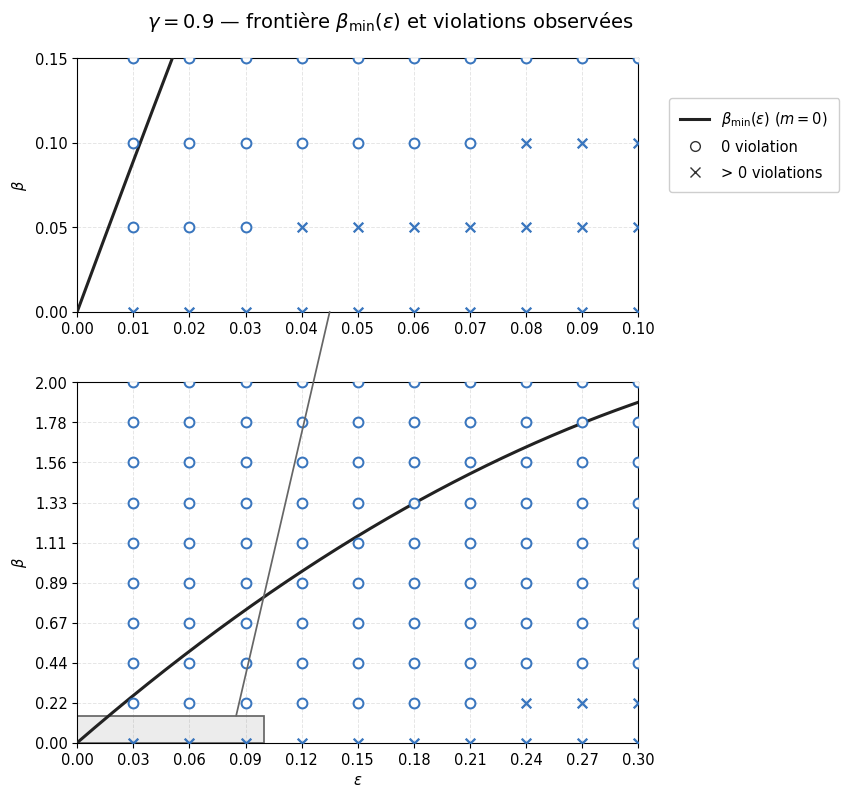

Figure sauvegardée dans `experiments/jpo_exps/revealing_check_jpo/fib_upperbound/gamma_0p9_fullgrid_fib_zoom.png`.

In [3]:
def beta_min(epsilon, gamma=TARGET_GAMMA):
    epsilon = np.asarray(epsilon, dtype=float)
    return gamma * epsilon * (1.0 - epsilon) / (1.0 - gamma)

def add_grid_points(ax, sources):
    for source in sources:
        subset = frame[frame['experiment'] == source['label']]
        zero = subset[~subset['violating']]
        positive = subset[subset['violating']]
        ax.scatter(
            zero['epsilon'], zero['beta'], s=50, marker='o',
            facecolors='white', edgecolors=source['color'], linewidths=1.45,
            alpha=0.95, zorder=4,
        )
        ax.scatter(
            positive['epsilon'], positive['beta'], s=48, marker='x',
            color=source['color'], linewidths=1.65, alpha=0.95, zorder=5,
        )

epsilon_dense = np.linspace(0.0, 0.3, 1200)
with plt.rc_context({
    'font.size': 10.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': True,
    'grid.alpha': 0.32,
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
}):
    fig = plt.figure(figsize=(9.2, 8.1))
    grid = fig.add_gridspec(2, 1, height_ratios=[0.95, 1.35], hspace=0.23)
    ax_zoom = fig.add_subplot(grid[0])
    ax_full = fig.add_subplot(grid[1])

    for ax in (ax_zoom, ax_full):
        ax.plot(
            epsilon_dense, beta_min(epsilon_dense),
            color='#222222', linewidth=2.2, zorder=3,
        )
        ax.set_ylabel(r'$\beta$')

    add_grid_points(ax_zoom, [SOURCES[1]])
    add_grid_points(ax_full, [SOURCES[0]])

    zoom_xlim = (0.0, 0.10)
    zoom_ylim = (0.0, 0.15)
    ax_zoom.set_xlim(*zoom_xlim)
    ax_zoom.set_ylim(*zoom_ylim)
    ax_zoom.set_xticks(np.arange(0.0, 0.101, 0.01))
    ax_zoom.set_yticks(np.arange(0.0, 0.151, 0.05))

    ax_full.set_xlim(0.0, 0.30)
    ax_full.set_ylim(0.0, 2.0)
    full_grid = frame[frame['experiment'] == SOURCES[0]['label']]
    full_epsilons = np.sort(full_grid['epsilon'].unique())
    full_betas = np.sort(full_grid['beta'].unique())
    full_x_ticks = np.insert(full_epsilons, 0, 0.0)
    ax_full.set_xticks(full_x_ticks, [f'{value:.2f}' for value in full_x_ticks])
    ax_full.set_yticks(full_betas, [f'{value:.2f}' for value in full_betas])
    ax_full.set_xlabel(r'$\epsilon$')

    zoom_rectangle = Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
        facecolor=(0.55, 0.55, 0.55, 0.16),
        edgecolor='#666666', linewidth=1.25, zorder=2,
    )
    ax_full.add_patch(zoom_rectangle)

    connector = ConnectionPatch(
        xyA=(0.085, zoom_ylim[1]), coordsA='data', axesA=ax_full,
        xyB=(0.045, zoom_ylim[0]), coordsB='data', axesB=ax_zoom,
        color='#666666', linewidth=1.25,
        clip_on=False, zorder=1,
    )
    fig.add_artist(connector)

    legend_handles = [
        Line2D([0], [0], color='#222222', lw=2.2,
               label=r'$\beta_{\min}(\epsilon)$ ($m=0$)'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=7,
               markerfacecolor='white', markeredgecolor='#333333', label='0 violation'),
        Line2D([0], [0], marker='x', linestyle='None', markersize=7,
               color='#333333', label='> 0 violations'),
    ]
    fig.legend(
        handles=legend_handles, loc='upper left', bbox_to_anchor=(0.735, 0.885),
        frameon=True, framealpha=0.96, borderpad=0.8, labelspacing=0.75,
    )
    fig.suptitle(
        r'$\gamma=0.9$ — frontière $\beta_{\min}(\epsilon)$ et violations observées',
        x=0.44, y=0.985, fontsize=14,
    )
    fig.subplots_adjust(left=0.10, right=0.71, bottom=0.08, top=0.925)
    fig.savefig(OUTPUT, dpi=220, bbox_inches='tight')
    plt.show()

display(Markdown(f'Figure sauvegardée dans `{OUTPUT.relative_to(REPOSITORY_ROOT)}`.'))

## Variante compacte — zoom à gauche, légende à droite

Cette seconde composition reprend l'organisation de la figure de référence : le panneau agrandi occupe seulement la partie supérieure gauche, tandis que la grille FIB complète utilise toute la largeur.

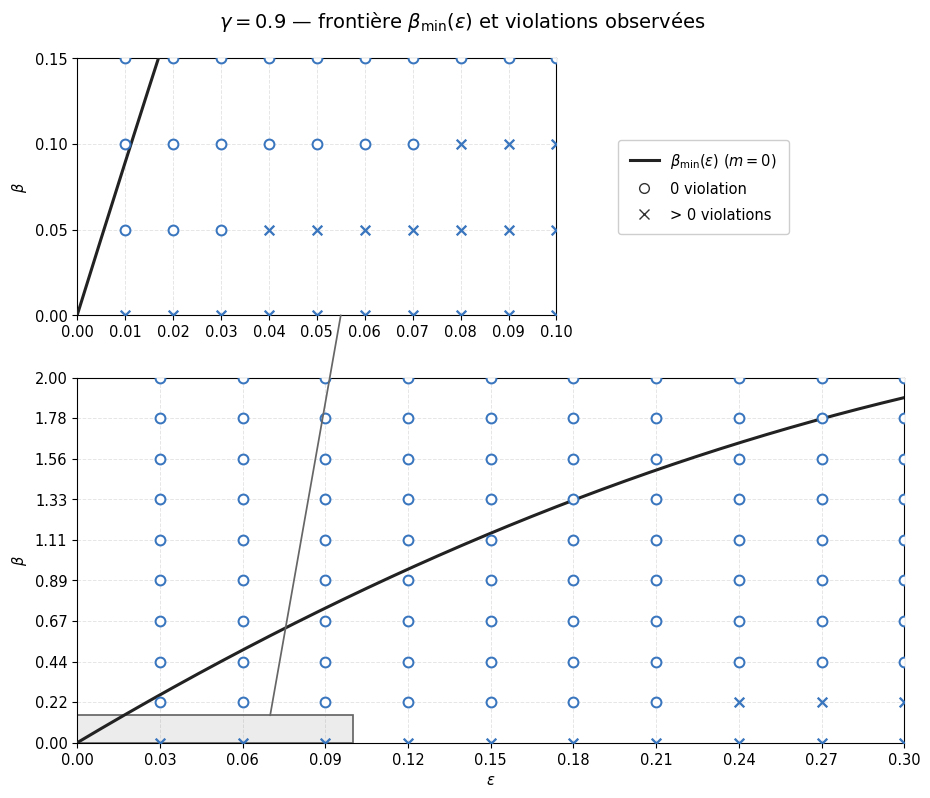

Variante compacte sauvegardée dans `experiments/jpo_exps/revealing_check_jpo/fib_upperbound/gamma_0p9_fullgrid_fib_zoom_compact.png`.

In [4]:
OUTPUT_COMPACT = OUTPUT_DIR / 'gamma_0p9_fullgrid_fib_zoom_compact.png'

with plt.rc_context({
    'font.size': 10.5,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.grid': True,
    'grid.alpha': 0.32,
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
}):
    fig_compact = plt.figure(figsize=(9.4, 8.1))
    compact_grid = fig_compact.add_gridspec(
        2, 2, width_ratios=[0.62, 0.38], height_ratios=[0.95, 1.35],
        hspace=0.20, wspace=0.14,
    )
    ax_zoom_compact = fig_compact.add_subplot(compact_grid[0, 0])
    ax_legend = fig_compact.add_subplot(compact_grid[0, 1])
    ax_full_compact = fig_compact.add_subplot(compact_grid[1, :])
    ax_legend.axis('off')

    for ax in (ax_zoom_compact, ax_full_compact):
        ax.plot(
            epsilon_dense, beta_min(epsilon_dense),
            color='#222222', linewidth=2.2, zorder=3,
        )
        ax.set_ylabel(r'$\beta$')

    add_grid_points(ax_zoom_compact, [SOURCES[1]])
    add_grid_points(ax_full_compact, [SOURCES[0]])

    ax_zoom_compact.set_xlim(*zoom_xlim)
    ax_zoom_compact.set_ylim(*zoom_ylim)
    ax_zoom_compact.set_xticks(np.arange(0.0, 0.101, 0.01))
    ax_zoom_compact.set_yticks(np.arange(0.0, 0.151, 0.05))

    ax_full_compact.set_xlim(0.0, 0.30)
    ax_full_compact.set_ylim(0.0, 2.0)
    ax_full_compact.set_xticks(
        full_x_ticks, [f'{value:.2f}' for value in full_x_ticks],
    )
    ax_full_compact.set_yticks(
        full_betas, [f'{value:.2f}' for value in full_betas],
    )
    ax_full_compact.set_xlabel(r'$\epsilon$')

    compact_rectangle = Rectangle(
        (zoom_xlim[0], zoom_ylim[0]),
        zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
        facecolor=(0.55, 0.55, 0.55, 0.16),
        edgecolor='#666666', linewidth=1.25, zorder=2,
    )
    ax_full_compact.add_patch(compact_rectangle)

    compact_connector = ConnectionPatch(
        xyA=(0.070, zoom_ylim[1]), coordsA='data', axesA=ax_full_compact,
        xyB=(0.055, zoom_ylim[0]), coordsB='data', axesB=ax_zoom_compact,
        color='#666666', linewidth=1.25,
        clip_on=False, zorder=1,
    )
    fig_compact.add_artist(compact_connector)

    ax_legend.legend(
        handles=legend_handles, loc='center left',
        frameon=True, framealpha=0.96, borderpad=0.8, labelspacing=0.75,
    )
    fig_compact.suptitle(
        r'$\gamma=0.9$ — frontière $\beta_{\min}(\epsilon)$ et violations observées',
        x=0.50, y=0.985, fontsize=14,
    )
    fig_compact.subplots_adjust(
        left=0.09, right=0.97, bottom=0.08, top=0.925,
    )
    fig_compact.savefig(OUTPUT_COMPACT, dpi=220, bbox_inches='tight')
    plt.show()

display(Markdown(
    f'Variante compacte sauvegardée dans `{OUTPUT_COMPACT.relative_to(REPOSITORY_ROOT)}`.'
))

## Lecture

Les deux grilles utilisent le même MDP seed 1111. Le panneau complet montre les résultats FIB jusqu'à $\epsilon=0.30$ et $\beta=2$, tandis que le panneau `t500` conserve le zoom de l'expérience précédente. Tous les points sont représentés de manière identique ; seuls la forme du marqueur et le nombre de violations distinguent les politiques.